This notebook is a localization problem. Where I simulate the performance of a single contrast localizer of different thresholds compared to  multitask localizers

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.cm as cm
import os


# first check for multitask how good the different eigen criteria are at parcellating region of interest vs everything else

In [2]:
save_dir = os.path.abspath(os.path.join(os.getcwd(),'..','eval_tsvs'))
saved_file = os.path.join(save_dir, 'sim_localization.tsv')
df = pd.read_csv(saved_file, sep='\t')

In [3]:
# defube metrics to plot
multi_metric_of_interest = 'inverse_trace_mc'
df_multi = df[(df['simulation_type'] == 'multi') & (df['metric'].isin([multi_metric_of_interest]))]
df_single = df[df['simulation_type'] == 'single']


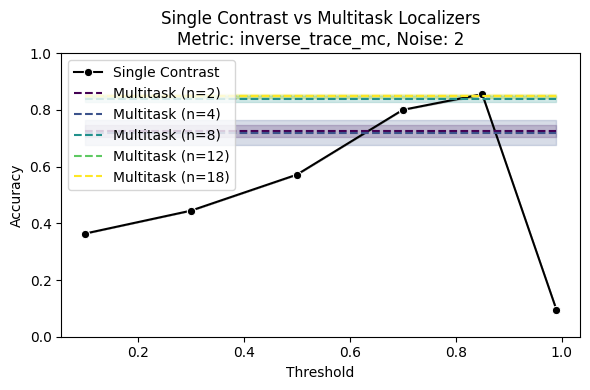

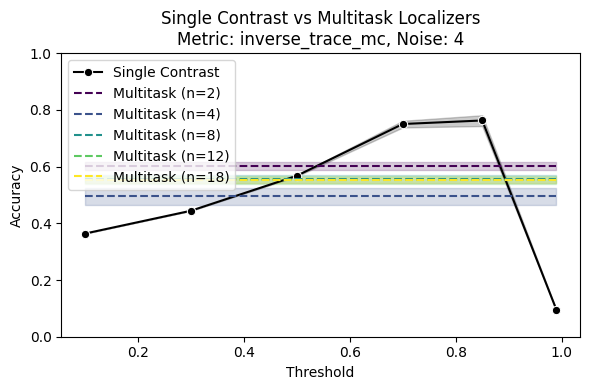

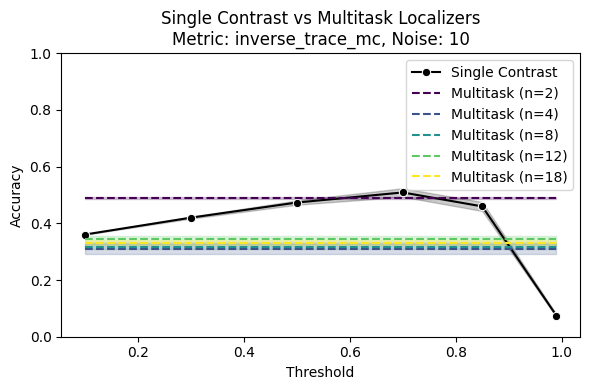

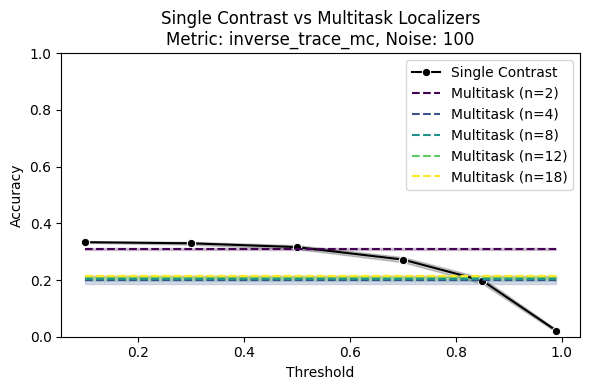

In [4]:
for noise in sorted(df['base_noise'].unique()):
    # Filter for current base_noise
    d_multi_n = df_multi[df_multi['base_noise'] == noise]
    d_single_n = df_single[df_single['base_noise'] == noise]

    # Compute summary stats for multitask
    summary_multi = d_multi_n.groupby('n_task')['accuracy'].agg(['mean', 'sem']).reset_index()
    summary_multi.columns = ['n_task', 'mean_accuracy', 'sem_accuracy']

    # Set up the plot for single contrast
    plt.figure(figsize=(6, 4))
    sns.lineplot(data=d_single_n, x="threshold", y="accuracy", label='Single Contrast', color='black', marker='o')

    # Add multitask performance lines
    colors = cm.viridis(np.linspace(0, 1, len(summary_multi)))
    xmin = min(d_single_n['threshold'])
    xmax = max(d_single_n['threshold'])

    for i, row in summary_multi.iterrows():
        mean = row['mean_accuracy']
        sem = row['sem_accuracy']
        n_task = row['n_task']

        plt.hlines(
            y=mean,
            xmin=xmin,
            xmax=xmax,
            colors=[colors[i]],
            linestyles='dashed',
            label=f'Multitask (n={int(n_task)})'
        )

        plt.fill_between(
            [xmin, xmax],
            [mean - sem],
            [mean + sem],
            color=colors[i],
            alpha=0.2
        )

    plt.xlabel('Threshold')
    plt.ylabel('Accuracy')
    # sey y-axis limits to 1 
    plt.ylim(0, 1)
    plt.title(f'Single Contrast vs Multitask Localizers\nMetric: {multi_metric_of_interest}, Noise: {noise}')
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()